In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Config
INPUT_FILE = "quotes.xlsx"   # adjust path as needed
SHEET_NAME = "Sheet1"
PRICE_COL_START = 1
PRICE_COL_END = 12


In [11]:
import openpyxl

# Find total row count without loading the full file
wb = openpyxl.load_workbook(INPUT_FILE, read_only=True, data_only=True)
ws = wb[SHEET_NAME]
total_rows = ws.max_row - 1  # exclude header
wb.close()

#skip = max(0, total_rows -500)
skip=600
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME, skiprows=range(1, skip + 1))
print(f"Loaded {len(df):,} rows x {len(df.columns)} columns (last 1,000 of {total_rows:,})")

# Extract price columns (B-Z), forward-fill missing values
prices = df.iloc[:, PRICE_COL_START:PRICE_COL_END].copy()
prices = prices.replace("", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Missing before ffill: {prices.isna().sum().sum():,}")
prices = prices.ffill()
print(f"Missing after ffill:  {prices.isna().sum().sum():,}")
prices.head()

Loaded 4,053 rows x 26 columns (last 1,000 of 8,484)
Missing before ffill: 2,882
Missing after ffill:  2,828


,GasTTFDAYSPOTM,GasTTFMTBALSPOTM,GasTTFMONTHMM,GasTTFMONTHM+1M,GasTTFMONTHM+2M,GasTTFMONTHM+3M,GasTTFMONTHM+4M,GasTTFMONTHM+5M,GasTTFQTR01SPOTM,GasTTFQTR02SPOTM,GasTTFQTR03SPOTM
0,13.225,12.90,12.80,12.90,12.900,NaN,NaN,NaN,13.150,16.325,18.025
1,12.700,12.25,12.60,12.70,12.675,NaN,NaN,NaN,12.825,16.050,17.750
2,13.000,12.95,12.80,12.90,12.900,NaN,NaN,NaN,13.100,16.550,17.950
3,13.450,13.50,13.85,14.00,14.000,NaN,NaN,NaN,14.500,17.900,19.300
4,14.075,14.40,15.10,15.45,15.450,NaN,NaN,NaN,15.300,17.975,19.825


In [12]:
# Log returns: ln(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()
print(f"Observations: {len(log_returns):,}")
print(f"Variables:    {log_returns.shape[1]}")
log_returns.describe().round(6)

Observations: 2,691
Variables:    11


,GasTTFDAYSPOTM,GasTTFMTBALSPOTM,GasTTFMONTHMM,GasTTFMONTHM+1M,GasTTFMONTHM+2M,GasTTFMONTHM+3M,GasTTFMONTHM+4M,GasTTFMONTHM+5M,GasTTFQTR01SPOTM,GasTTFQTR02SPOTM,GasTTFQTR03SPOTM
count,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000,2691.000000
mean,0.000137,0.000146,0.000148,0.000152,0.000151,0.000143,0.000134,inf,0.000143,0.000114,0.000136
std,0.063794,0.053546,0.047111,0.043433,0.040922,0.040492,0.038598,NaN,0.042623,0.039539,0.036047
min,-1.012300,-0.673345,-0.315785,-0.316891,-0.302564,-0.492382,-0.300814,-0.502231,-0.311843,-0.649853,-0.413078
25%,-0.020540,-0.019698,-0.019720,-0.018204,-0.016421,-0.015599,-0.014673,-0.013536,-0.016638,-0.013613,-0.012285
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.021092,0.018659,0.018995,0.017534,0.016002,0.015122,0.014389,0.014398,0.015807,0.014294,0.012713
max,0.922560,0.777888,0.393800,0.359635,0.369480,0.347620,0.348233,inf,0.528590,0.348294,0.331113


In [ ]:
# Drop columns with inf or NaN (e.g. TTFMONTHM+5M has inf log-returns)
log_returns = log_returns.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
n_components = log_returns.shape[1]
print(f"Using {n_components} columns after removing inf/NaN columns")

# Standardise (zero mean, unit variance) -> correlation-based PCA
Z = StandardScaler().fit_transform(log_returns)

# Fit PCA
pca = PCA(n_components=n_components)
pca.fit(Z)

# Build results
pc_labels = [f"PC{i+1}" for i in range(n_components)]
var_pct = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_pct)

summary = pd.DataFrame({
    "Eigenvalue": pca.explained_variance_,
    "Variance %": var_pct,
    "Cumulative %": cum_var
}, index=pc_labels)

loadings = pd.DataFrame(
    pca.components_.T,
    index=log_returns.columns,
    columns=pc_labels
)

summary


Using 10 columns after removing inf/NaN columns


,Eigenvalue,Variance %,Cumulative %
PC1,8.114935,81.119189,81.119189
PC2,0.635156,6.349197,87.468386
PC3,0.382443,3.823006,91.291393
PC4,0.263284,2.631858,93.923251
PC5,0.221679,2.215964,96.139215
PC6,0.159236,1.591766,97.730980
PC7,0.104904,1.048653,98.779633
PC8,0.066727,0.667019,99.446652
PC9,0.038187,0.381724,99.828377
PC10,0.017169,0.171623,100.000000


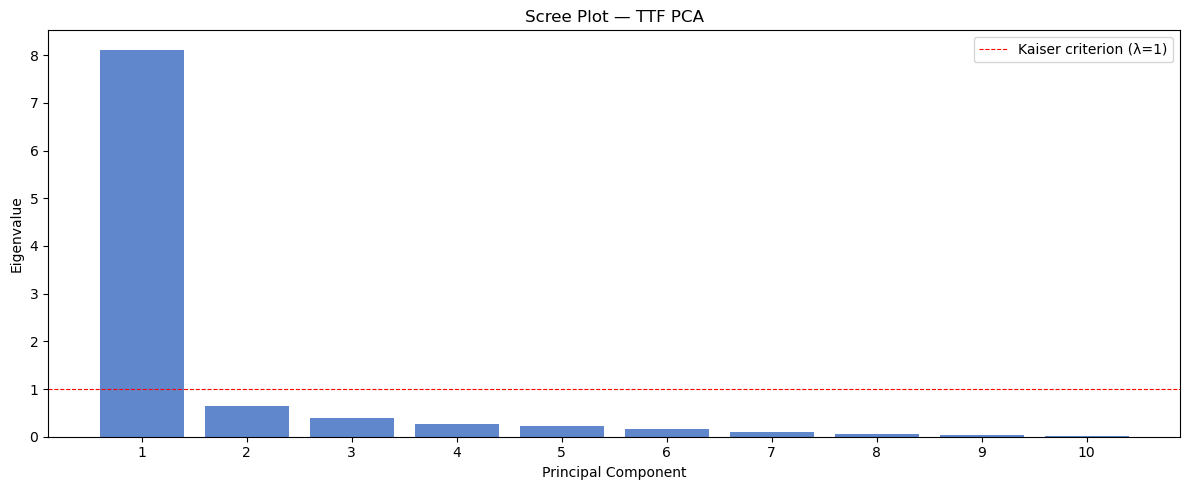

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, n_components + 1), pca.explained_variance_, color="#4472C4", alpha=0.85)
ax.axhline(y=1, color="red", linestyle="--", lw=0.8, label="Kaiser criterion (λ=1)")
ax.set(xlabel="Principal Component", ylabel="Eigenvalue", title="Scree Plot — TTF PCA")
ax.set_xticks(range(1, n_components + 1))
ax.legend()
plt.tight_layout()
plt.show()


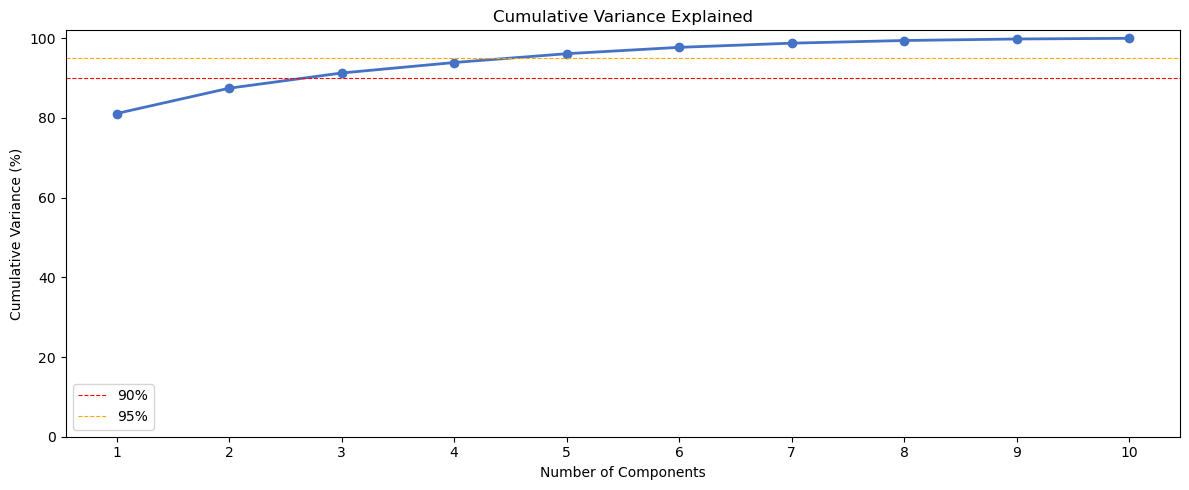

PC1: 81.1% (Level)
PC2: 6.3% (Slope)
PC3: 3.8% (Curvature)
Top 3: 91.3%


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, n_components + 1), cum_var, "o-", color="#4472C4", lw=2)
ax.axhline(y=90, color="red", linestyle="--", lw=0.8, label="90%")
ax.axhline(y=95, color="orange", linestyle="--", lw=0.8, label="95%")
ax.set(xlabel="Number of Components", ylabel="Cumulative Variance (%)",
       title="Cumulative Variance Explained")
ax.set_xticks(range(1, n_components + 1))
ax.set_ylim(0, 102)
ax.legend()
plt.tight_layout()
plt.show()

print(f"PC1: {var_pct[0]:.1f}% (Level)")
print(f"PC2: {var_pct[1]:.1f}% (Slope)")
print(f"PC3: {var_pct[2]:.1f}% (Curvature)")
print(f"Top 3: {cum_var[2]:.1f}%")


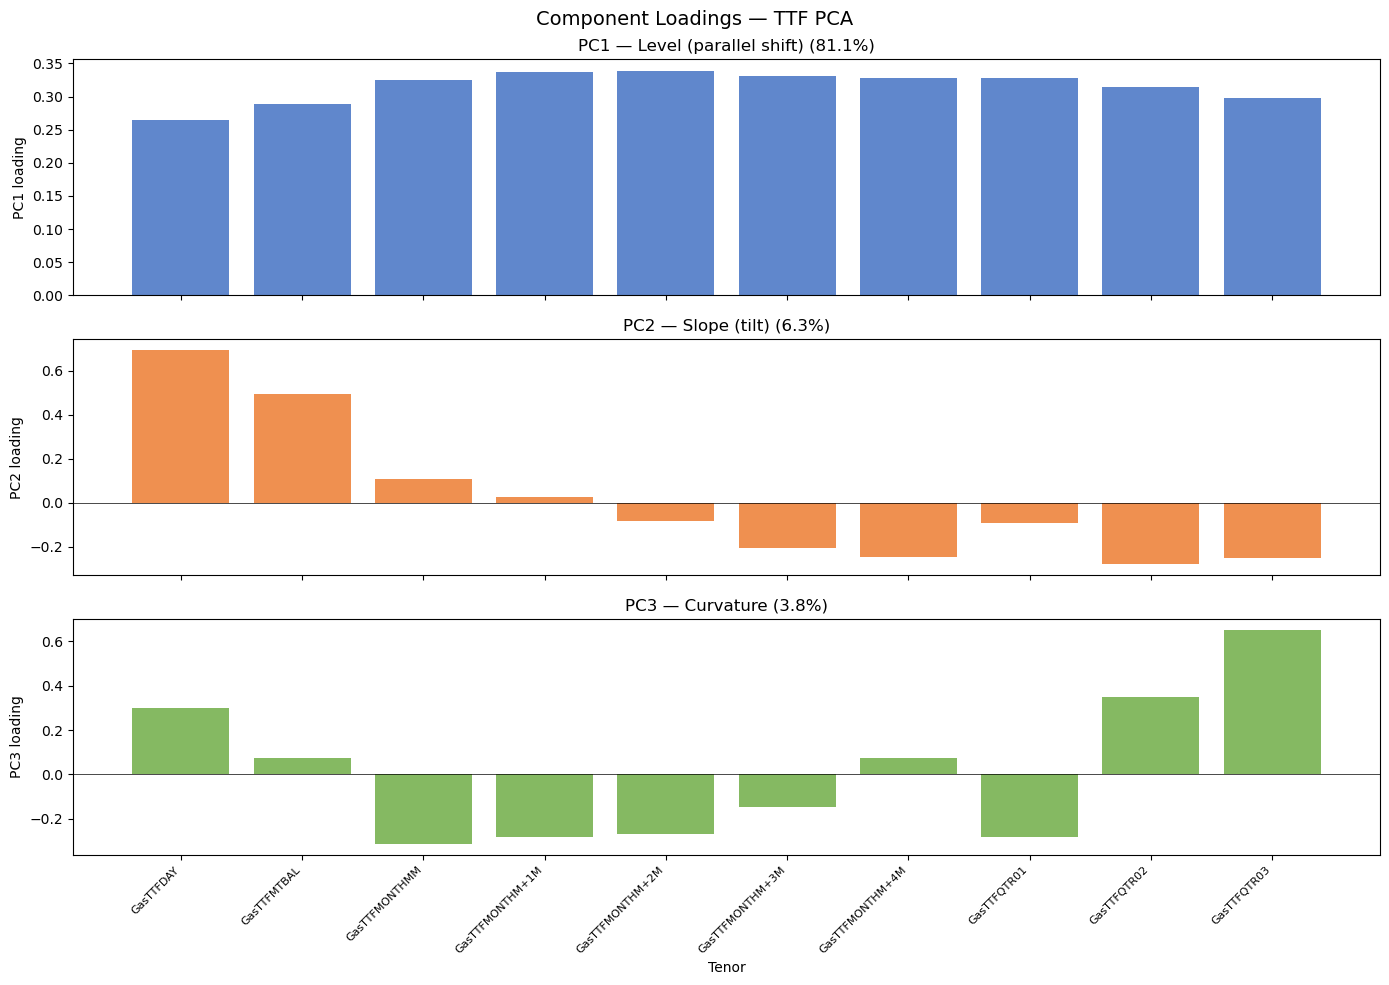

In [20]:

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ["#4472C4", "#ED7D31", "#70AD47"]
names = ["Level (parallel shift)", "Slope (tilt)", "Curvature"]

for i, ax in enumerate(axes):
    ax.bar(range(n_components), loadings[f"PC{i+1}"], color=colors[i], alpha=0.85)
    ax.axhline(y=0, color="k", lw=0.5)
    ax.set_ylabel(f"PC{i+1} loading")
    ax.set_title(f"PC{i+1} — {names[i]} ({var_pct[i]:.1f}%)")

axes[-1].set_xticks(range(n_components))
axes[-1].set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
axes[-1].set_xlabel("Tenor")
plt.suptitle("Component Loadings — TTF PCA", fontsize=14)
plt.tight_layout()
plt.show()